In [1]:
import scipy.io as sio
import numpy as np
import mne
import mne_connectivity
import os
import warnings
warnings.filterwarnings('ignore')
mne.set_log_level('ERROR')
print("Imports OK")

Imports OK


In [3]:
BASE = r'D:\Data science Project\EEG Chrononet\EEGdata\Data\CleanData'

CHANNELS = ['AF3','F7','F3','FC5','T7','P7','O1','O2','P8','T8','FC6','F4','F8','AF4']
SFREQ     = 128
WIN_SEC   = 8
OVERLAP   = 0.5
WIN_SAMP  = WIN_SEC * SFREQ           # 1024
STEP_SAMP = int(WIN_SAMP * (1-OVERLAP))  # 512

BANDS = {
    'delta': (1,  4),
    'theta': (4,  8),
    'alpha': (8,  13),
    'beta' : (13, 30),
    'gamma': (30, 45),
}
FMIN       = [v[0] for v in BANDS.values()]
FMAX       = [v[1] for v in BANDS.values()]
BAND_NAMES = list(BANDS.keys())
N_BANDS    = len(BANDS)
N_CH       = len(CHANNELS)
PAIRS      = [(i,j) for i in range(N_CH) for j in range(i+1, N_CH)]
N_PAIRS    = len(PAIRS)   # 91

print(f"Channels : {N_CH}")
print(f"Pairs    : {N_PAIRS}")
print(f"Bands    : {BAND_NAMES}")
print(f"Window   : {WIN_SEC}s  Overlap: {int(OVERLAP*100)}%")

Channels : 14
Pairs    : 91
Bands    : ['delta', 'theta', 'alpha', 'beta', 'gamma']
Window   : 8s  Overlap: 50%


In [5]:
MANIFEST = [
    ('NDS001','IDD','Music', os.path.join(BASE,'CleanData_IDD','Music','NDS001_Music_CD.mat')),
    ('NDS001','IDD','Rest',  os.path.join(BASE,'CleanData_IDD','Rest', 'NDS001_Rest_CD.mat')),
    ('NDS002','IDD','Music', os.path.join(BASE,'CleanData_IDD','Music','NDS002_Music_CD.mat')),
    ('NDS002','IDD','Rest',  os.path.join(BASE,'CleanData_IDD','Rest', 'NDS002_Rest_CD.mat')),
    ('NDS003','IDD','Music', os.path.join(BASE,'CleanData_IDD','Music','NDS003_Music_CD.mat')),
    ('NDS003','IDD','Rest',  os.path.join(BASE,'CleanData_IDD','Rest', 'NDS003_Rest_CD.mat')),
    ('NDS004','IDD','Music', os.path.join(BASE,'CleanData_IDD','Music','NDS004_Music_CD.mat')),
    ('NDS004','IDD','Rest',  os.path.join(BASE,'CleanData_IDD','Rest', 'NDS004_Rest_CD.mat')),
    ('NDS005','IDD','Music', os.path.join(BASE,'CleanData_IDD','Music','NDS005_Music_CD.mat')),
    ('NDS005','IDD','Rest',  os.path.join(BASE,'CleanData_IDD','Rest', 'NDS005_Rest_CD.mat')),
    ('NDS006','IDD','Music', os.path.join(BASE,'CleanData_IDD','Music','NDS006_Music_CD.mat')),
    ('NDS006','IDD','Rest',  os.path.join(BASE,'CleanData_IDD','Rest', 'NDS006_Rest_CD.mat')),
    ('NDS007','IDD','Music', os.path.join(BASE,'CleanData_IDD','Music','NDS007_Music_CD.mat')),
    ('NDS007','IDD','Rest',  os.path.join(BASE,'CleanData_IDD','Rest', 'NDS007_Rest_CD.mat')),
    ('CGS01','TDC','Music', os.path.join(BASE,'CleanData_TDC','Music','CGS01_Music_CD.mat')),
    ('CGS01','TDC','Rest',  os.path.join(BASE,'CleanData_TDC','Rest', 'CGS01_Rest_CD.mat')),
    ('CGS02','TDC','Music', os.path.join(BASE,'CleanData_TDC','Music','CGS02_Music_CD.mat')),
    ('CGS02','TDC','Rest',  os.path.join(BASE,'CleanData_TDC','Rest', 'CGS02_Rest_CD.mat')),
    ('CGS03','TDC','Music', os.path.join(BASE,'CleanData_TDC','Music','CGS03_Music_CD.mat')),
    ('CGS03','TDC','Rest',  os.path.join(BASE,'CleanData_TDC','Rest', 'CGS03_Rest_CD.mat')),
    ('CGS04','TDC','Music', os.path.join(BASE,'CleanData_TDC','Music','CGS04_Music_CD.mat')),
    ('CGS04','TDC','Rest',  os.path.join(BASE,'CleanData_TDC','Rest', 'CGS04_Rest_CD.mat')),
    ('CGS05','TDC','Music', os.path.join(BASE,'CleanData_TDC','Music','CGS05_Music_CD.mat')),
    ('CGS05','TDC','Rest',  os.path.join(BASE,'CleanData_TDC','Rest', 'CGS05_Rest_CD.mat')),
    ('CGS06','TDC','Music', os.path.join(BASE,'CleanData_TDC','Music','CGS06_Music_CD.mat')),
    ('CGS06','TDC','Rest',  os.path.join(BASE,'CleanData_TDC','Rest', 'CGS06_Rest_CD.mat')),
    ('CGS07','TDC','Music', os.path.join(BASE,'CleanData_TDC','Music','CGS07_Music_CD.mat')),
    ('CGS07','TDC','Rest',  os.path.join(BASE,'CleanData_TDC','Rest', 'CGS07_Rest_CD.mat')),
]
print(f"Manifest entries: {len(MANIFEST)}")

Manifest entries: 28


In [7]:
info = mne.create_info(ch_names=CHANNELS, sfreq=SFREQ, ch_types='eeg')

data = {}
errors = []

for subj, group, cond, fpath in MANIFEST:
    fname = os.path.basename(fpath)
    if not os.path.exists(fpath):
        print(f"MISSING: {fname}")
        errors.append(fname)
        continue
    mat = sio.loadmat(fpath)
    arr = mat['clean_data'].astype(np.float32)
    data[(subj, cond)] = {'eeg': arr, 'group': group, 'subj': subj, 'cond': cond}

print(f"Loaded : {len(data)}/28")
print(f"Errors : {len(errors)}")
if not errors:
    print("✅ All files loaded")

Loaded : 28/28
Errors : 0
✅ All files loaded


In [9]:
def make_epochs(arr):
    """(14, 15360) -> MNE EpochsArray with 8s/50% overlap"""
    n_samples = arr.shape[1]
    starts = np.arange(0, n_samples - WIN_SAMP + 1, STEP_SAMP)
    epochs = np.stack([arr[:, s:s+WIN_SAMP] for s in starts], axis=0)
    return mne.EpochsArray(epochs.astype(np.float64), info, verbose=False)

def compute_wpli(epochs):
    """MNE Epochs -> wPLI matrix (91, 5)"""
    conn = mne_connectivity.spectral_connectivity_epochs(
        epochs,
        method   = 'wpli2_debiased',
        fmin     = FMIN,
        fmax     = FMAX,
        faverage = True,
        verbose  = False,
    )
    raw = conn.get_data()              # (196, 5)
    mat = raw.reshape(N_CH, N_CH, N_BANDS)
    wpli = np.array([mat[i,j,:] for (i,j) in PAIRS])  # (91, 5)
    return wpli.astype(np.float32)

print("Helper functions defined")

Helper functions defined


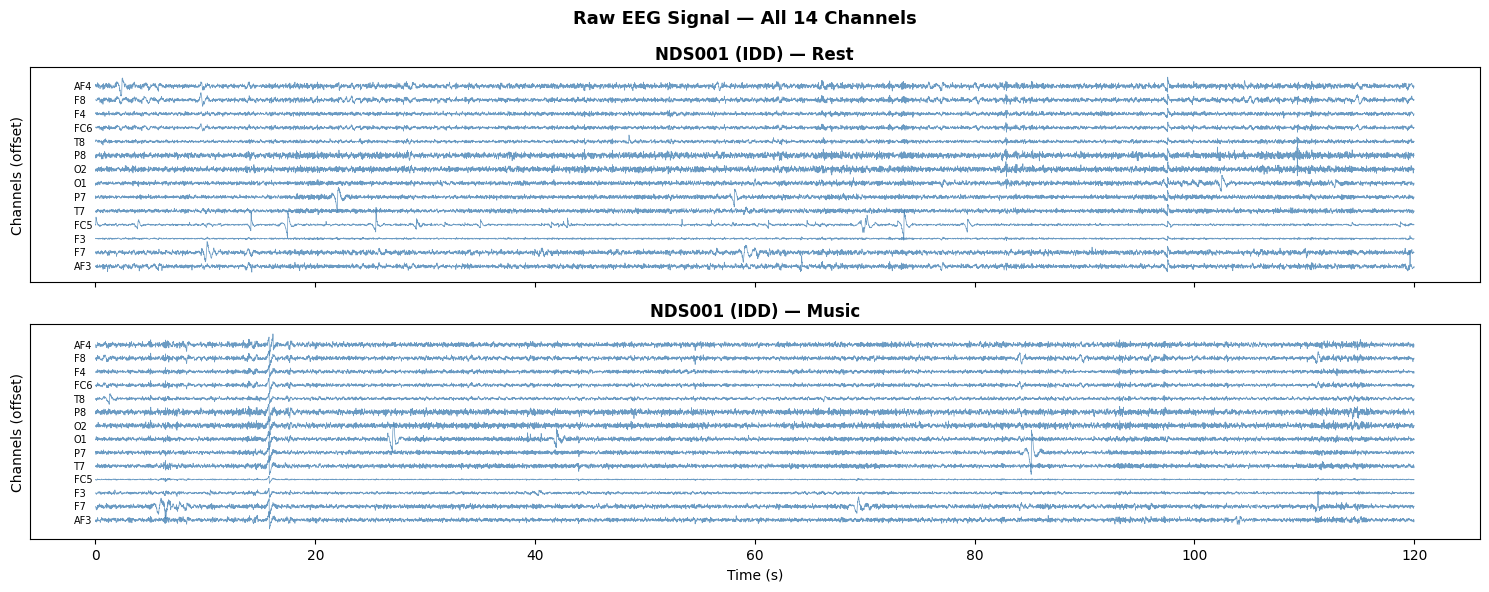

Saved: fig_raw_signal.png


In [11]:
import matplotlib.pyplot as plt

subj = 'NDS001'
fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)

for ax, cond in zip(axes, ['Rest', 'Music']):
    eeg = data[(subj, cond)]['eeg']
    group = data[(subj, cond)]['group']
    t = np.arange(eeg.shape[1]) / SFREQ
    
    offset = 0
    for ch_idx, ch_name in enumerate(CHANNELS):
        ax.plot(t, eeg[ch_idx] + offset, linewidth=0.5, color='steelblue', alpha=0.8)
        ax.text(-2, offset, ch_name, fontsize=7, va='center')
        offset += 150
    
    ax.set_title(f'{subj} ({group}) — {cond}', fontweight='bold')
    ax.set_ylabel('Channels (offset)')
    ax.set_yticks([])

axes[-1].set_xlabel('Time (s)')
plt.suptitle('Raw EEG Signal — All 14 Channels', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r'D:\Data science Project\EEG Chrononet\EEGdata\fig_raw_signal.png', dpi=150)
plt.show()
print("Saved: fig_raw_signal.png")

In [13]:
import os
import matplotlib.pyplot as plt
import matplotlib as mpl

# ── Publishable style config (run once, applies to all cells) ──
FIG_DIR = r'D:\Data science Project\EEG Chrononet\EEGdata\figures'
os.makedirs(FIG_DIR, exist_ok=True)

mpl.rcParams.update({
    'font.size'        : 14,
    'font.weight'      : 'bold',
    'axes.titlesize'   : 16,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 14,
    'axes.labelweight' : 'bold',
    'xtick.labelsize'  : 12,
    'ytick.labelsize'  : 12,
    'legend.fontsize'  : 12,
    'figure.dpi'       : 100,
    'savefig.dpi'      : 600,
    'savefig.bbox'     : 'tight',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

def save_fig(fname):
    path = os.path.join(FIG_DIR, fname)
    plt.savefig(path, dpi=600, bbox_inches='tight')
    print(f"Saved: {path}")

print(f"Figure folder: {FIG_DIR}")
print("Style config applied ✅")

Figure folder: D:\Data science Project\EEG Chrononet\EEGdata\figures
Style config applied ✅


Saved: D:\Data science Project\EEG Chrononet\EEGdata\figures\fig_psd.png


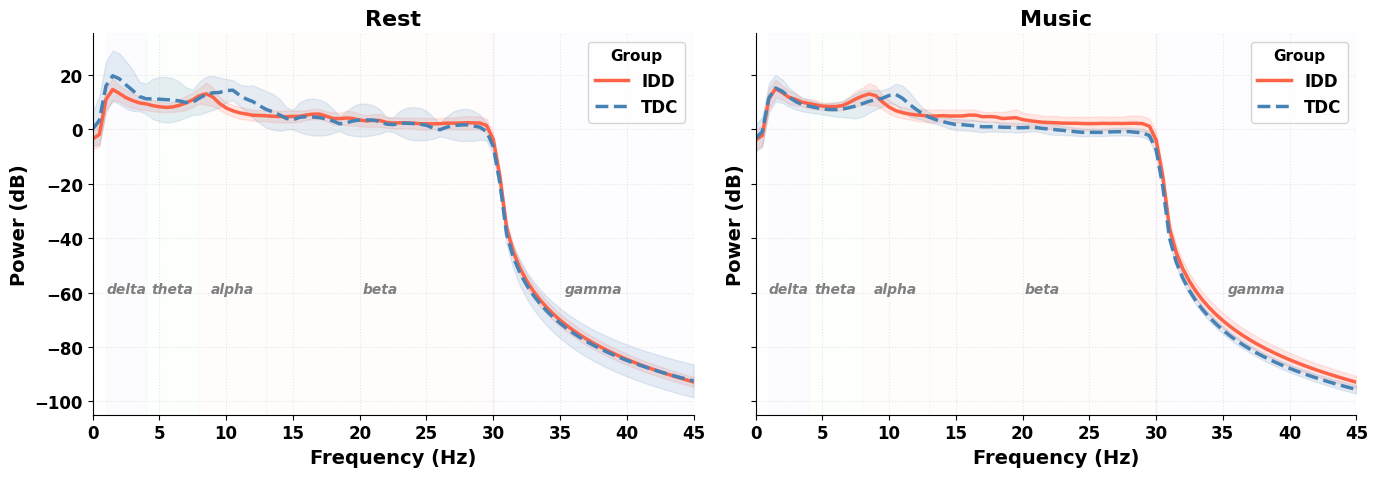

In [15]:
from scipy.signal import welch

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, cond in zip(axes, ['Rest', 'Music']):
    for group, color, ls in [('IDD','tomato','-'), ('TDC','steelblue','--')]:
        psds = []
        for (subj, c), rec in data.items():
            if c != cond or rec['group'] != group:
                continue
            eeg = rec['eeg'].astype(np.float64)
            freqs, psd = welch(eeg, fs=SFREQ, nperseg=256)
            psds.append(10 * np.log10(psd.mean(axis=0) + 1e-12))

        psds    = np.array(psds)
        mask    = freqs <= 45
        mean_psd = psds.mean(axis=0)
        std_psd  = psds.std(axis=0)

        ax.plot(freqs[mask], mean_psd[mask],
                color=color, ls=ls, linewidth=2.5, label=group)
        ax.fill_between(freqs[mask],
                        mean_psd[mask] - std_psd[mask],
                        mean_psd[mask] + std_psd[mask],
                        color=color, alpha=0.15)

    # Band shading
    band_colors = ['#e8e8ff','#e8ffe8','#fff0e8','#ffe8e8','#f0e8ff']
    for (bname, (flo, fhi)), bc in zip(BANDS.items(), band_colors):
        ax.axvspan(flo, fhi, alpha=0.12, color=bc)
        ax.text((flo+fhi)/2, ax.get_ylim()[0] if ax.get_ylim()[0] > -100 else -60,
                bname, ha='center', fontsize=10, fontstyle='italic', color='gray')

    ax.set_title(f'{cond}')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Power (dB)')
    ax.legend(title='Group', title_fontsize=11)
    ax.set_xlim(0, 45)
    ax.grid(True, alpha=0.3, linestyle=':')

plt.tight_layout()
save_fig('fig_psd.png')
plt.show()

Saved: D:\Data science Project\EEG Chrononet\EEGdata\figures\fig_bandpower_heatmap.png


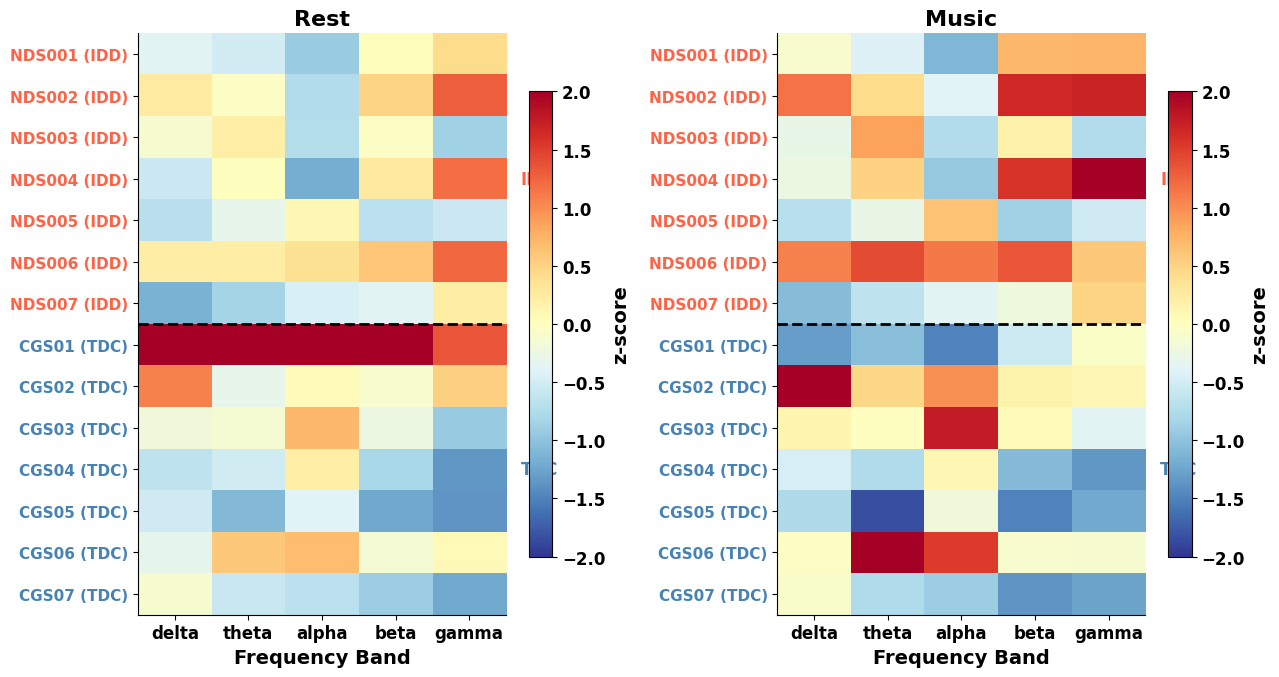

In [17]:
from scipy.signal import welch

fig, axes = plt.subplots(1, 2, figsize=(13, 7))

for ax, cond in zip(axes, ['Rest', 'Music']):
    bp_matrix  = []
    row_labels = []
    row_colors = []

    for subj, group, c, _ in MANIFEST:
        if c != cond:
            continue
        eeg = data[(subj, c)]['eeg'].astype(np.float64)
        freqs, psd = welch(eeg, fs=SFREQ, nperseg=256)
        psd_mean = psd.mean(axis=0)

        row = []
        for bname, (flo, fhi) in BANDS.items():
            mask = (freqs >= flo) & (freqs < fhi)
            row.append(psd_mean[mask].mean())
        bp_matrix.append(row)
        row_labels.append(f"{subj} ({group})")
        row_colors.append('tomato' if group == 'IDD' else 'steelblue')

    bp_matrix = np.array(bp_matrix)
    bp_log    = np.log10(bp_matrix + 1e-12)
    bp_norm   = (bp_log - bp_log.mean(axis=0)) / (bp_log.std(axis=0) + 1e-8)

    im = ax.imshow(bp_norm, aspect='auto', cmap='RdYlBu_r', vmin=-2, vmax=2)

    ax.set_xticks(range(N_BANDS))
    ax.set_xticklabels(BAND_NAMES)
    ax.set_yticks(range(14))
    ax.set_yticklabels(row_labels, fontsize=11)

    # Color y-tick labels by group
    for ytick, color in zip(ax.get_yticklabels(), row_colors):
        ytick.set_color(color)

    ax.set_title(f'{cond}')
    ax.set_xlabel('Frequency Band')

    # Divider line between IDD (0-6) and TDC (7-13)
    ax.axhline(6.5, color='black', linewidth=2, linestyle='--')
    ax.text(4.7, 3,  'IDD', fontsize=12, color='tomato',    va='center', fontweight='bold')
    ax.text(4.7, 10, 'TDC', fontsize=12, color='steelblue', va='center', fontweight='bold')

    plt.colorbar(im, ax=ax, label='z-score', shrink=0.8)

plt.tight_layout()
save_fig('fig_bandpower_heatmap.png')
plt.show()

Saved: D:\Data science Project\EEG Chrononet\EEGdata\figures\fig_group_signal.png


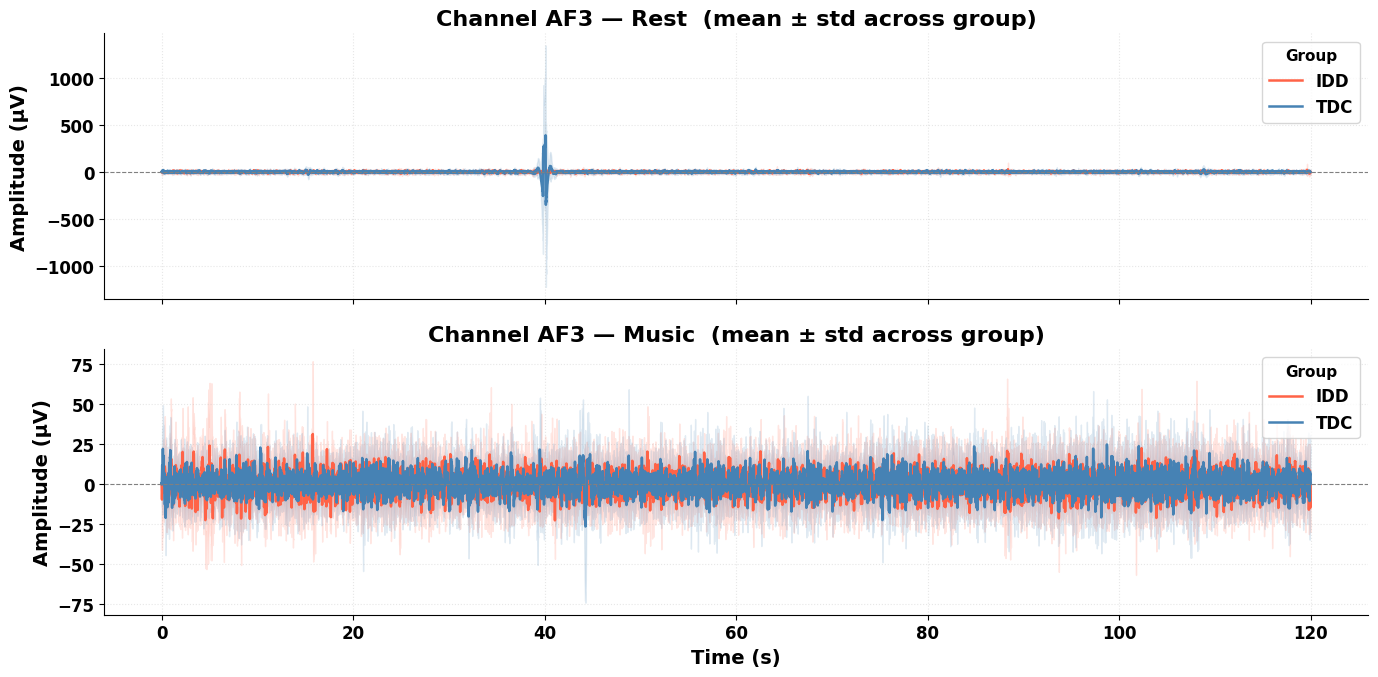

In [19]:
ch_idx = CHANNELS.index('AF3')
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for ax, cond in zip(axes, ['Rest', 'Music']):
    t = np.arange(15360) / SFREQ

    for group, color in [('IDD','tomato'), ('TDC','steelblue')]:
        signals = []
        for (subj, c), rec in data.items():
            if c == cond and rec['group'] == group:
                signals.append(rec['eeg'][ch_idx])
        signals  = np.array(signals)
        mean_sig = signals.mean(axis=0)
        std_sig  = signals.std(axis=0)

        ax.plot(t, mean_sig, color=color, linewidth=1.8, label=group)
        ax.fill_between(t,
                        mean_sig - std_sig,
                        mean_sig + std_sig,
                        color=color, alpha=0.15)

    ax.set_title(f'Channel AF3 — {cond}  (mean ± std across group)')
    ax.set_ylabel('Amplitude (µV)')
    ax.legend(title='Group', title_fontsize=11, loc='upper right')
    ax.grid(True, alpha=0.3, linestyle=':')
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
save_fig('fig_group_signal.png')
plt.show()

Saved: D:\Data science Project\EEG Chrononet\EEGdata\figures\fig_group_signal_clipped.png


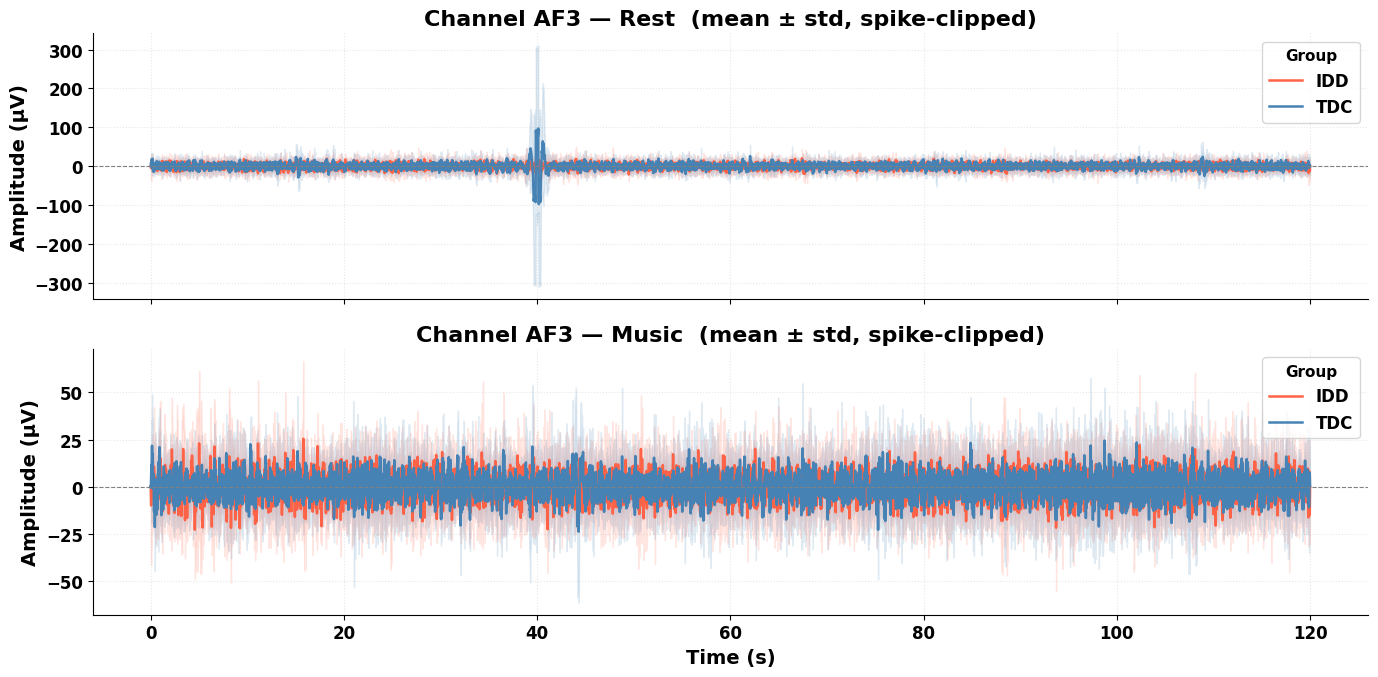

In [21]:
ch_idx = CHANNELS.index('AF3')
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for ax, cond in zip(axes, ['Rest', 'Music']):
    t = np.arange(15360) / SFREQ

    for group, color in [('IDD','tomato'), ('TDC','steelblue')]:
        signals = []
        for (subj, c), rec in data.items():
            if c == cond and rec['group'] == group:
                sig = rec['eeg'][ch_idx].copy()
                # Clip per-subject signal at ±5 std to suppress outlier spikes
                std = sig.std()
                sig = np.clip(sig, -5*std, 5*std)
                signals.append(sig)

        signals  = np.array(signals)
        mean_sig = signals.mean(axis=0)
        std_sig  = signals.std(axis=0)

        ax.plot(t, mean_sig, color=color, linewidth=1.8, label=group)
        ax.fill_between(t,
                        mean_sig - std_sig,
                        mean_sig + std_sig,
                        color=color, alpha=0.15)

    ax.set_title(f'Channel AF3 — {cond}  (mean ± std, spike-clipped)')
    ax.set_ylabel('Amplitude (µV)')
    ax.legend(title='Group', title_fontsize=11, loc='upper right')
    ax.grid(True, alpha=0.3, linestyle=':')
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
save_fig('fig_group_signal_clipped.png')
plt.show()

Saved: D:\Data science Project\EEG Chrononet\EEGdata\figures\fig_corr_matrix.png


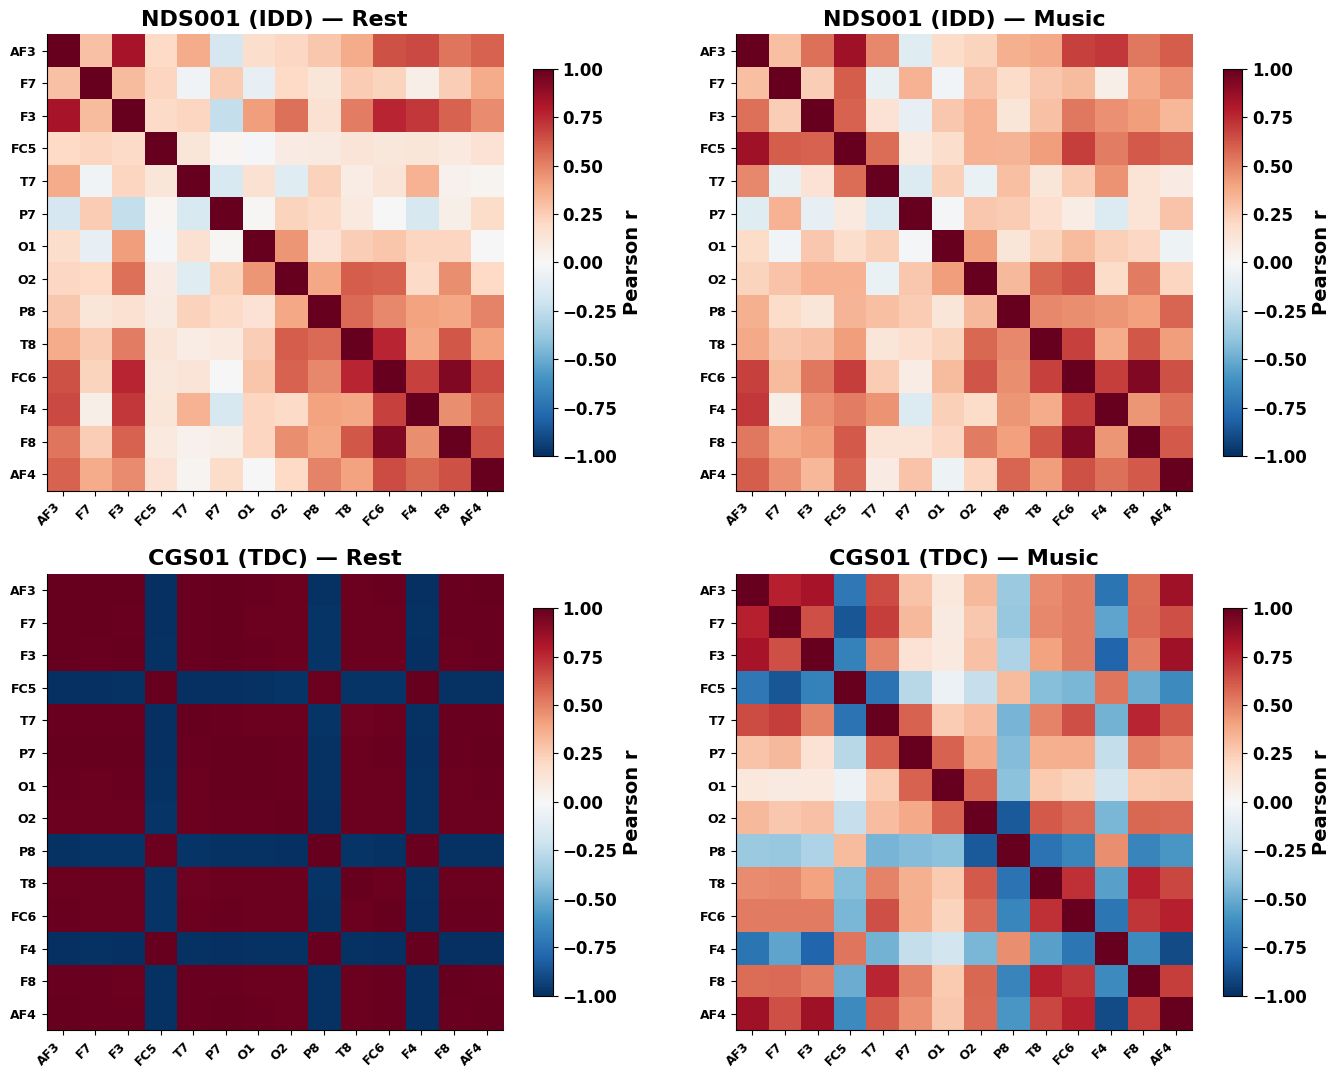

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for row, subj in enumerate(['NDS001', 'CGS01']):
    group = 'IDD' if subj.startswith('N') else 'TDC'
    for col, cond in enumerate(['Rest', 'Music']):
        ax  = axes[row][col]
        eeg = data[(subj, cond)]['eeg']   # (14, 15360)

        # Clip at 5-std per channel before correlation
        eeg_c = eeg.copy()
        for ch in range(14):
            s = eeg_c[ch].std()
            eeg_c[ch] = np.clip(eeg_c[ch], -5*s, 5*s)

        corr = np.corrcoef(eeg_c)         # (14, 14)

        im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
        ax.set_xticks(range(N_CH))
        ax.set_xticklabels(CHANNELS, rotation=45, fontsize=9, ha='right')
        ax.set_yticks(range(N_CH))
        ax.set_yticklabels(CHANNELS, fontsize=9)
        ax.set_title(f'{subj} ({group}) — {cond}')
        plt.colorbar(im, ax=ax, label='Pearson r', shrink=0.85)

plt.tight_layout()
save_fig('fig_corr_matrix.png')
plt.show()

In [25]:
# Scan all subjects/conditions for signal quality issues
print(f"{'Subject':<10} {'Group':<6} {'Cond':<7} {'MaxAmp':>10} {'MeanCorr':>10} {'FlatSec':>10} {'Flag'}")
print("-" * 65)

FLAT_THRESH  = 0.95   # mean off-diagonal correlation above this = suspicious
AMP_THRESH   = 500    # µV — max amplitude above this = suspicious

flagged = []

for subj, group, cond, _ in MANIFEST:
    eeg = data[(subj, cond)]['eeg'].copy()  # (14, 15360)

    # 1. Max amplitude
    max_amp = np.abs(eeg).max()

    # 2. Mean off-diagonal correlation
    corr = np.corrcoef(eeg)
    mask = ~np.eye(14, dtype=bool)
    mean_corr = np.abs(corr[mask]).mean()

    # 3. Flat seconds — count samples where ALL channels change < 0.01
    diff = np.abs(np.diff(eeg, axis=1))
    flat_samples = (diff.max(axis=0) < 0.01).sum()
    flat_sec = flat_samples / SFREQ

    flags = []
    if max_amp  > AMP_THRESH : flags.append('HIGH_AMP')
    if mean_corr > FLAT_THRESH: flags.append('HIGH_CORR')
    if flat_sec  > 1.0        : flags.append('FLAT')

    flag_str = ', '.join(flags) if flags else 'OK'
    if flags:
        flagged.append((subj, cond, flag_str))

    marker = ' <<<' if flags else ''
    print(f"{subj:<10} {group:<6} {cond:<7} {max_amp:>10.1f} {mean_corr:>10.4f} {flat_sec:>10.2f}   {flag_str}{marker}")

print()
print(f"Total flagged: {len(flagged)}")
for s, c, f in flagged:
    print(f"  {s} {c}: {f}")

Subject    Group  Cond        MaxAmp   MeanCorr    FlatSec Flag
-----------------------------------------------------------------
NDS001     IDD    Music        250.6     0.3590       0.00   OK
NDS001     IDD    Rest         188.6     0.3025       0.00   OK
NDS002     IDD    Music        351.0     0.3528       0.00   OK
NDS002     IDD    Rest         167.5     0.3539       0.00   OK
NDS003     IDD    Music        102.3     0.4156       0.00   OK
NDS003     IDD    Rest         224.2     0.4066       0.00   OK
NDS004     IDD    Music        151.2     0.2652       0.00   OK
NDS004     IDD    Rest        1099.0     0.3276       0.00   HIGH_AMP <<<
NDS005     IDD    Music        138.0     0.5414       0.00   OK
NDS005     IDD    Rest         108.5     0.4287       0.00   OK
NDS006     IDD    Music        143.8     0.4207       0.00   OK
NDS006     IDD    Rest         532.8     0.3485       0.00   HIGH_AMP <<<
NDS007     IDD    Music        162.7     0.4288       0.00   OK
NDS007     IDD    

Saved: D:\Data science Project\EEG Chrononet\EEGdata\figures\fig_CGS01_inspection.png


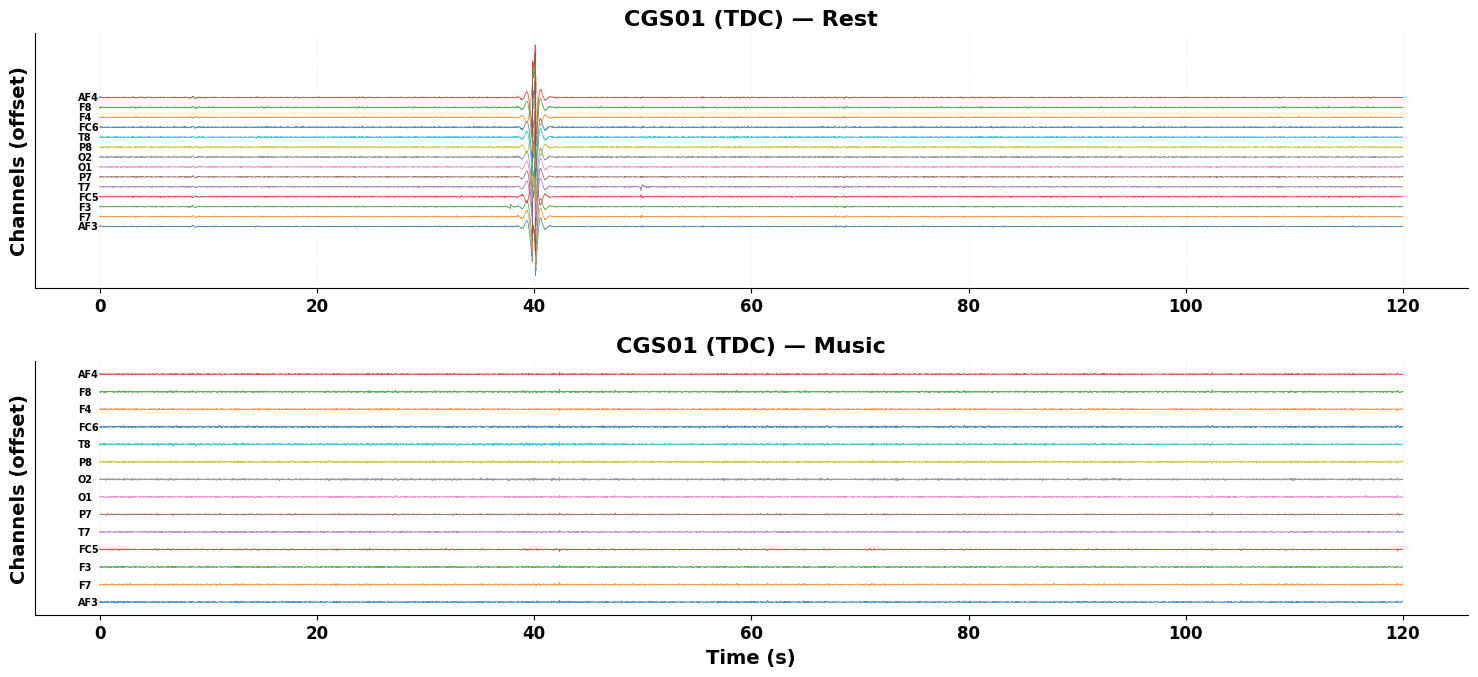

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(15, 7))

for ax, (subj, cond) in zip(axes, [('CGS01','Rest'), ('CGS01','Music')]):
    eeg   = data[(subj, cond)]['eeg']
    group = data[(subj, cond)]['group']
    t     = np.arange(eeg.shape[1]) / SFREQ

    offset = 0
    for ch_idx, ch_name in enumerate(CHANNELS):
        ax.plot(t, eeg[ch_idx] + offset, linewidth=0.6, alpha=0.8)
        ax.text(-2, offset, ch_name, fontsize=7, va='center')
        offset += 500   # wider spacing to see spikes clearly

    ax.set_title(f'CGS01 ({group}) — {cond}')
    ax.set_ylabel('Channels (offset)')
    ax.set_yticks([])
    ax.grid(True, alpha=0.2, linestyle=':')

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
save_fig('fig_CGS01_inspection.png')
plt.show()

In [29]:
def make_epochs_clean(arr, subj='', cond='', amp_thresh=300.0, verbose=True):
    """
    Build 8s/50%-overlap epochs, dropping any window where
    peak amplitude exceeds amp_thresh (µV).
    Returns: clean EpochsArray, list of dropped window indices
    """
    n_samples = arr.shape[1]
    starts    = np.arange(0, n_samples - WIN_SAMP + 1, STEP_SAMP)

    kept    = []
    dropped = []

    for idx, s in enumerate(starts):
        window = arr[:, s:s+WIN_SAMP]
        if np.abs(window).max() > amp_thresh:
            dropped.append(idx)
        else:
            kept.append(window)

    if verbose:
        print(f"  {subj} {cond}: {len(kept)} epochs kept, "
              f"{len(dropped)} dropped (>{amp_thresh}µV) "
              f"at window idx {dropped}")

    epochs_arr = np.stack(kept, axis=0).astype(np.float64)
    return mne.EpochsArray(epochs_arr, info, verbose=False), dropped

# ── Test on all flagged + one clean subject ───────────────────
print("Epoch cleaning test:")
print("-" * 65)
test_cases = [
    ('CGS01', 'Rest'),
    ('CGS01', 'Music'),
    ('NDS004', 'Rest'),
    ('NDS006', 'Rest'),
    ('CGS02', 'Music'),
    ('NDS001', 'Rest'),   # clean reference
]

for subj, cond in test_cases:
    arr = data[(subj, cond)]['eeg']
    epochs, dropped = make_epochs_clean(arr, subj=subj, cond=cond,
                                         amp_thresh=300.0, verbose=True)

print()
print("✅ Epoch cleaner working — ready for wPLI computation")

Epoch cleaning test:
-----------------------------------------------------------------
  CGS01 Rest: 26 epochs kept, 3 dropped (>300.0µV) at window idx [8, 9, 10]
  CGS01 Music: 29 epochs kept, 0 dropped (>300.0µV) at window idx []
  NDS004 Rest: 27 epochs kept, 2 dropped (>300.0µV) at window idx [13, 14]
  NDS006 Rest: 27 epochs kept, 2 dropped (>300.0µV) at window idx [7, 8]
  CGS02 Music: 25 epochs kept, 4 dropped (>300.0µV) at window idx [6, 7, 10, 11]
  NDS001 Rest: 29 epochs kept, 0 dropped (>300.0µV) at window idx []

✅ Epoch cleaner working — ready for wPLI computation


Saved: D:\Data science Project\EEG Chrononet\EEGdata\figures\fig_erp.png


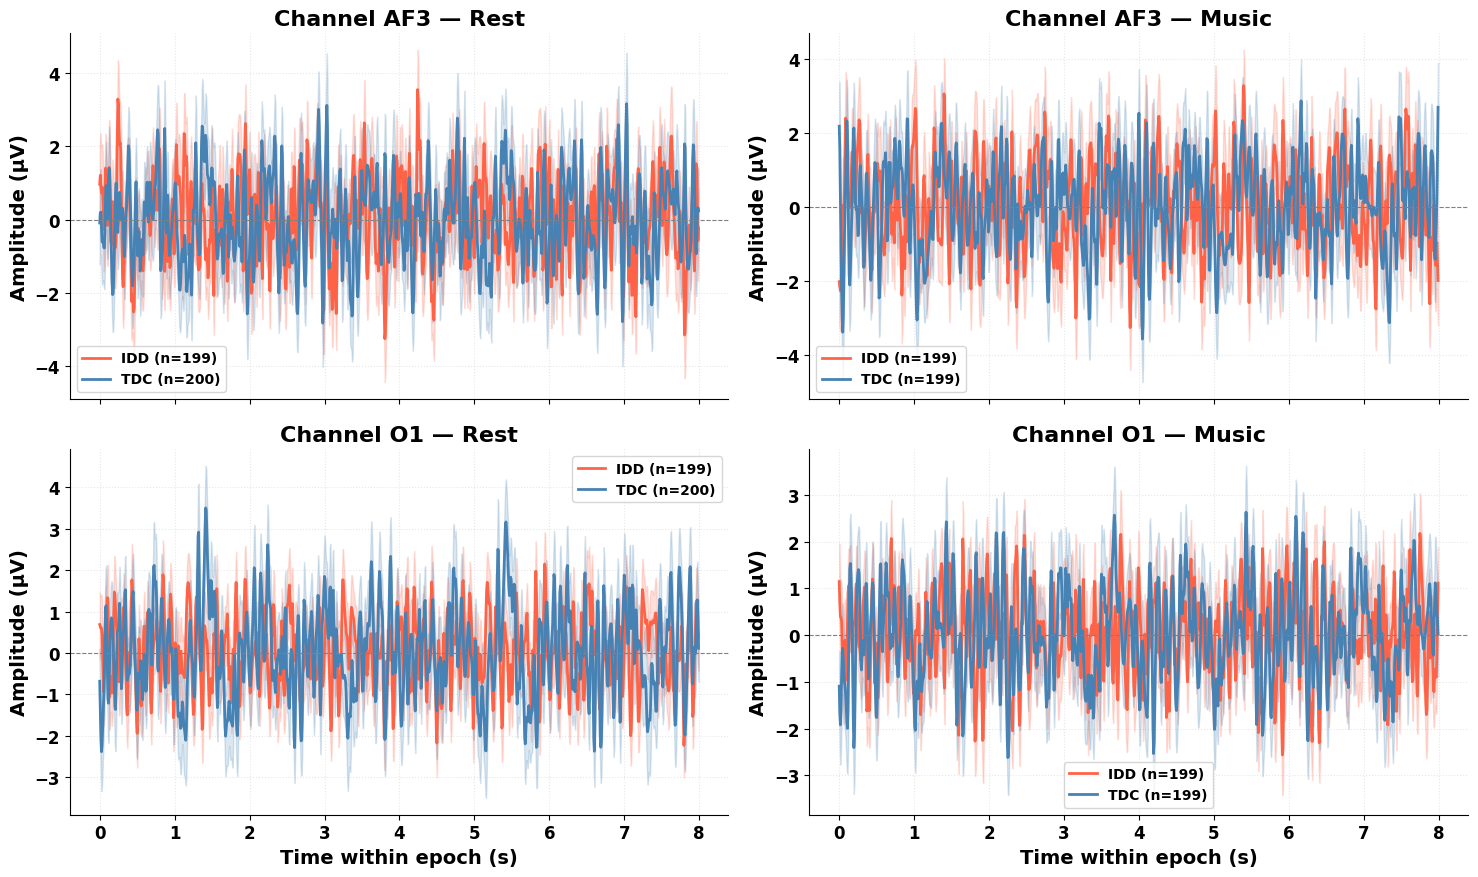

In [31]:
# ERP-style: average signal across all clean epochs per group/condition
# Shows time-domain brain response shape

fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True)

for col, cond in enumerate(['Rest', 'Music']):
    for row, ch_name in enumerate(['AF3', 'O1']):  # frontal + occipital
        ax     = axes[row][col]
        ch_idx = CHANNELS.index(ch_name)
        t      = np.arange(WIN_SAMP) / SFREQ  # 0 to 8s

        for group, color in [('IDD','tomato'), ('TDC','steelblue')]:
            all_epochs = []
            for subj, grp, c, _ in MANIFEST:
                if c != cond or grp != group:
                    continue
                arr = data[(subj, c)]['eeg']
                epochs, _ = make_epochs_clean(arr, amp_thresh=300.0, verbose=False)
                # epochs.get_data() shape: (n_epochs, 14, 1024)
                all_epochs.append(epochs.get_data()[:, ch_idx, :])  # (n_epochs, 1024)

            all_epochs = np.vstack(all_epochs)  # (total_epochs, 1024)
            mean_erp   = all_epochs.mean(axis=0)
            std_erp    = all_epochs.std(axis=0)
            sem_erp    = std_erp / np.sqrt(len(all_epochs))

            ax.plot(t, mean_erp, color=color, linewidth=2, label=f'{group} (n={len(all_epochs)})')
            ax.fill_between(t,
                            mean_erp - sem_erp,
                            mean_erp + sem_erp,
                            color=color, alpha=0.2)

        ax.set_title(f'Channel {ch_name} — {cond}')
        ax.set_ylabel('Amplitude (µV)')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3, linestyle=':')
        ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

axes[-1][0].set_xlabel('Time within epoch (s)')
axes[-1][1].set_xlabel('Time within epoch (s)')
plt.tight_layout()
save_fig('fig_erp.png')
plt.show()